In [2]:
import py_dss_interface
from py_dss_toolkit import dss_tools
import pandas as pd

dss = py_dss_interface.DSS()

dss_file = r"C:\Dados_teste\OpenDSS\CBA\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]


dfs_monitor = {}
df_energymeter = pd.DataFrame(columns=["Caso", "Perdas", "Energia"])
dfs_voltage = {}

for case in cases:

    dss.text(f"compile [{dss_file}]")

    if case == "60_gd":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
    
    elif case == "120_gd":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
    
    elif case == "60_gd_30_bess":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
        dss.text("Redirect 'BATERIAS_30.dss'")

    elif case == "120_gd_60_bess":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
        dss.text("Redirect 'BATERIAS_60.dss'")

    else:
        dss.text("!Redirect 'BATERIAS_60.dss'")
    
    dss.text(f"buscoords BusCoords.csv")

    dss.text("set mode=daily")
    dss.text("set stepsize=1h")
    dss.text("set number=1")

    for h in range(48):
        #if dss.solution.hour == 24:
            #dss.meters.reset_all()
        dss.solution.solve()

    #dss.text("sample")

    meter_values = dss.meters.register_values

    print(f"Energia total: {meter_values[0]:.2f} kWh")
    print(f"Perdas totais: {meter_values[12]:.2f} kWh")

    nova_linha = pd.DataFrame([{
        "Caso": f"{case}_df", "Energia": meter_values[0], "Perdas": meter_values[12]
    }])

    df_energymeter = pd.concat([df_energymeter, nova_linha], ignore_index=True)

    #Monitor - Power Flow
    dfs_monitor[f"{case}_df"] = dss_tools.results.monitor("feeder")
    dfs_monitor[f"{case}_df"]["Total Power"] = dfs_monitor[f"{case}_df"][' P1 (kW)'] + dfs_monitor[f"{case}_df"][' P2 (kW)'] + dfs_monitor[f"{case}_df"][' P3 (kW)']

    #Monitors - Voltage
    monitor_names = dss.monitors.names

    for monitor_name in monitor_names:
        if "voltage" in monitor_name.lower():
            dfs_voltage[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)


#display(dfs_monitor["120_gd_60_bess_df"])
display(df_energymeter)
print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)


Energia total: 248842.36 kWh
Perdas totais: 12555.75 kWh
Energia total: 157793.02 kWh
Perdas totais: 10697.10 kWh
Energia total: 151058.27 kWh
Perdas totais: 8292.68 kWh
Energia total: 98888.83 kWh
Perdas totais: 11764.93 kWh
Energia total: 85980.00 kWh
Perdas totais: 7032.36 kWh


,Caso,Perdas,Energia
0,base_df,12555.745538,248842.359518
1,60_gd_df,10697.098761,157793.016029
2,60_gd_30_bess_df,8292.68496,151058.27208
3,120_gd_df,11764.925372,98888.831402
4,120_gd_60_bess_df,7032.357661,85980.00236


Index(['Hour', 'sec', ' V1', ' VAngle1', ' V2', ' VAngle2', ' V3', ' VAngle3',
       ' V4', ' VAngle4', ' I1', ' IAngle1', ' I2', ' IAngle2', ' I3',
       ' IAngle3', ' I4', ' IAngle4'],
      dtype='str')


Dados de Potência

,Caso,Perdas,Energia
0,base_df,12555.745538,248842.359518
1,60_gd_df,10697.098761,157793.016029
2,60_gd_30_bess_df,8292.68496,151058.27208
3,120_gd_df,11764.925372,98888.831402
4,120_gd_60_bess_df,7032.357661,85980.00236


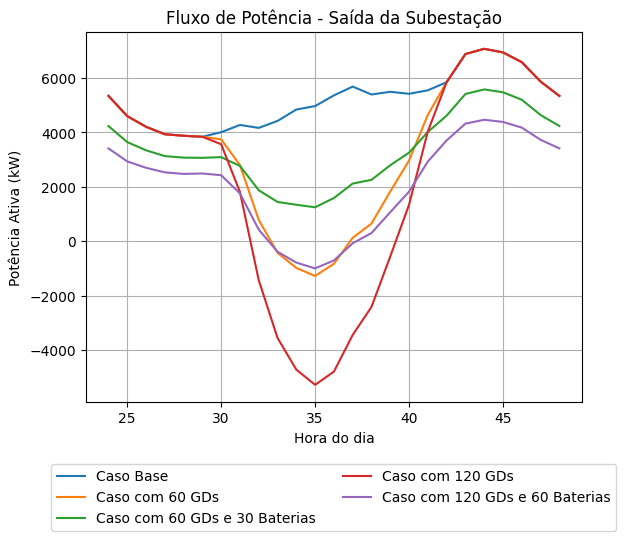

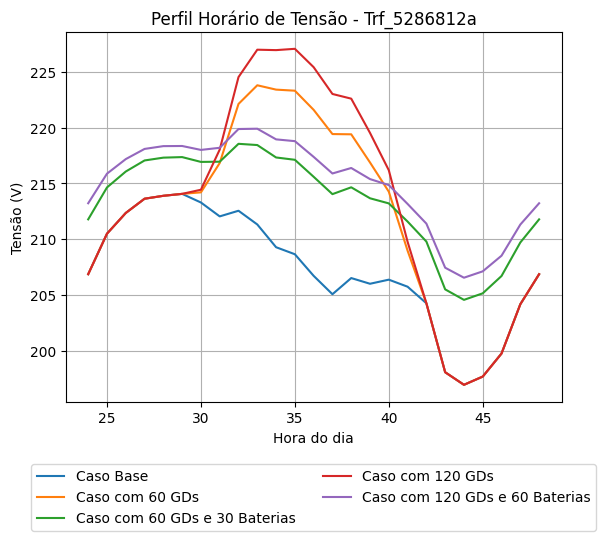

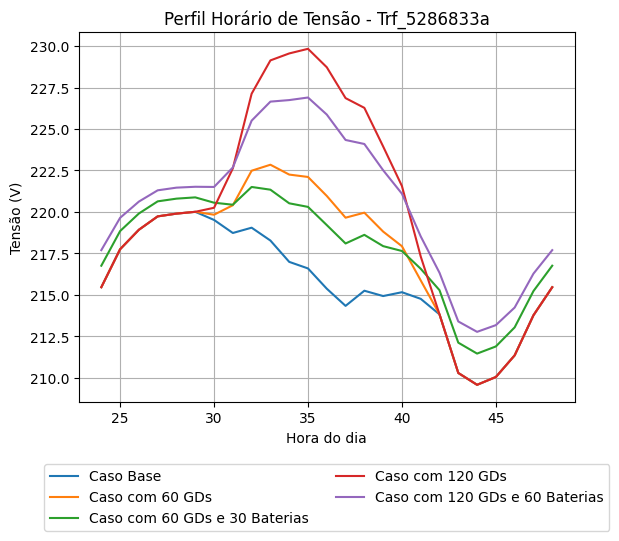

In [3]:
#Resultados

import matplotlib.pyplot as plt

display(df_energymeter)

titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}
#Gráfico Subestação Fluxo de Potência
for case in cases:
    dfs_monitor[f"{case}_df"] = dfs_monitor[f"{case}_df"].query("Hour > 23")
    plt.plot(
        dfs_monitor[f"{case}_df"]["Hour"], 
        dfs_monitor[f"{case}_df"]["Total Power"], label=titles[case])
    

plt.title("Fluxo de Potência - Saída da Subestação")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

#Gráfico Tensão Trf 5286812a
for case in cases:
    df1 = dfs_voltage[f"voltage_trf_5286812a_{case}_df"].query("Hour > 23")
    plt.plot(
        df1["Hour"], 
        df1[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286812a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

#Gráfico Tensão Trf_5286833a
for case in cases:
    df2= dfs_voltage[f"voltage_trf_5286833a_{case}_df"].query("Hour > 23")
    plt.plot(
        df2["Hour"], 
        df2[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286833a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.style.use("dark_background")
plt.show()



Version 11.0.0.1 (64-bit build) - Charlottesville; License Status: Open 


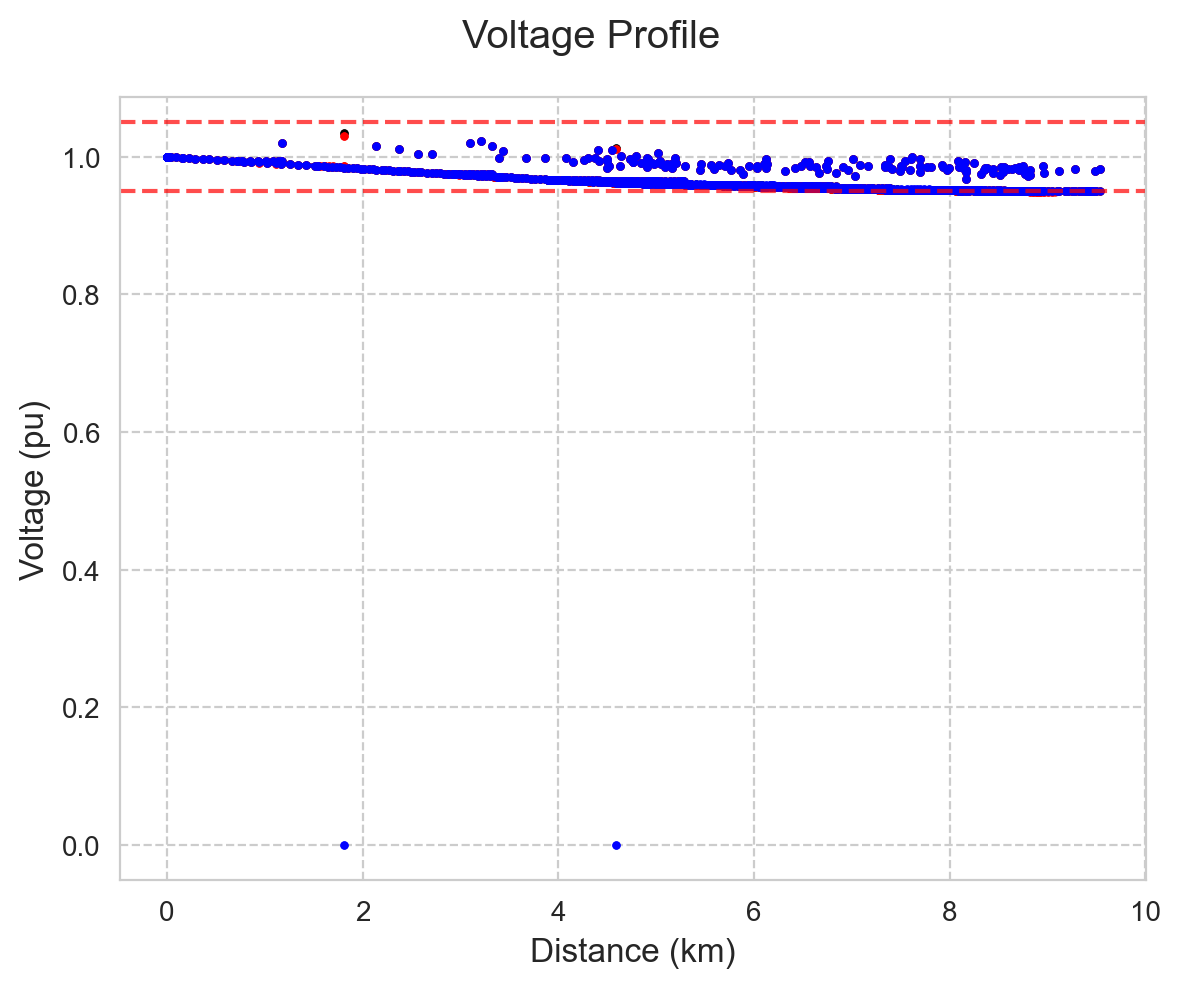

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='Distance (km)', ylabel='Voltage (pu)'>)

In [4]:
print(dss.dssinterface.version)

########## Mapas ############

dss_tools.interactive_view.circuit_plot(parameter="voltage", show=True)
#dss_tools.interactive_view.circuit_geoplot(show=True)
dss_tools.static_view.voltage_profile(show=True, legend=False)


In [ ]:
monitor_names = dss.monitors.names
cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]
voltages = ["V1", "V2", "V3"]

for monitor in monitor_names:
    if "voltage" not in monitor.lower():
        continue
    
    base = dfs_voltage[f"{monitor}_base_df"]

    for case in cases:
        df = dfs_voltage[f"{monitor}_{case}_df"]

        for v in voltages:

            if case == "base":
                df[f"diff_percent_{v}"] = 0.0
                continue
            
            if f" {v}" not in df.columns:
                continue

            df[f"diff_percent_{v}"] = 100*(df[f" {v}"] - base[f" {v}"])/base[f" {v}"]

estatisticas = []

for nome, df in dfs_voltage.items():

    linha = {"Monitor": nome}

    for v in voltages:

        if f" {v}" not in df.columns:
            continue

        linha[f"{v}_max"] = df[f" {v}"].max()
        linha[f"{v}_hora_max"] = df.loc[df[f" {v}"].idxmax(), "Hour"]
        linha[f"{v}_min"] = df[f" {v}"].min()
        linha[f"{v}_hora_min"] = df.loc[df[f" {v}"].idxmin(), "Hour"]
        linha[f"{v}_medio"] = df[f" {v}"].mean()

        if f"diff_percent_{v}" in df.columns:
            linha[f"diff_{v}_max"] = df[f"diff_percent_{v}"].max()
            linha[f"diff_{v}_hora_max"] = df.loc[df[f"diff_percent_{v}"].idxmax(), "Hour"]
            linha[f"diff_{v}_min"] = df[f"diff_percent_{v}"].min()
            linha[f"diff_{v}_hora_min"] = df.loc[df[f"diff_percent_{v}"].idxmin(), "Hour"]

    estatisticas.append(linha)

df_stats = pd.DataFrame(estatisticas)


df_stats = df_stats.sort_values(by='diff_V1_max', ascending=False)
display(df_stats)


#display(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"])
#print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)

,Monitor,V1_max,V1_hora_max,V1_min,V1_hora_min,V1_medio,diff_V1_max,diff_V1_hora_max,diff_V1_min,diff_V1_hora_min,...,diff_V2_hora_min,V3_max,V3_hora_max,V3_min,V3_hora_min,V3_medio,diff_V3_max,diff_V3_hora_max,diff_V3_min,diff_V3_hora_min
462,voltage_trf_5286812a_120_gd_df,227.060974,11.0,196.943939,20.0,213.607900,9.047834,12.0,0.000000,1.0,...,1.0,227.057983,11.0,196.940018,20.0,213.604889,9.047926,12.0,0.000000,1.0
606,voltage_trf_5286812a_120_gd_60_bess_df,225.365906,12.0,206.544479,20.0,215.553912,9.024648,12.0,2.004635,29.0,...,29.0,225.362701,12.0,206.540451,20.0,215.550907,9.024740,12.0,2.004656,29.0
460,voltage_trf_5286810a_120_gd_df,228.155777,11.0,200.046127,20.0,215.339741,8.478471,12.0,0.000000,1.0,...,1.0,228.152786,11.0,200.042130,20.0,215.336699,8.478569,12.0,0.000000,1.0
604,voltage_trf_5286810a_120_gd_60_bess_df,226.560928,12.0,208.421692,20.0,216.922509,8.452336,12.0,1.739769,29.0,...,29.0,226.557724,12.0,208.417618,20.0,216.919472,8.452434,12.0,1.739787,29.0
465,voltage_trf_5286815a_120_gd_df,228.450653,11.0,200.598709,20.0,215.682350,8.436846,12.0,0.000000,1.0,...,1.0,228.447662,11.0,200.594696,20.0,215.679305,8.436928,12.0,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,voltage_trf_5286718a_base_df,220.138412,5.0,209.753906,20.0,215.978222,0.000000,1.0,0.000000,1.0,...,1.0,220.136108,5.0,209.749695,20.0,215.975123,0.000000,1.0,0.000000,1.0
0,voltage_feeder_base_df,7967.323730,5.0,7967.270020,20.0,7967.299601,0.000000,1.0,0.000000,1.0,...,1.0,7967.951172,20.0,7967.716797,5.0,7967.813517,0.000000,1.0,0.000000,1.0
2,voltage_trf_5286707a_base_df,225.568893,5.0,220.531143,20.0,223.560966,0.000000,1.0,0.000000,1.0,...,1.0,225.568100,5.0,220.529663,20.0,223.559884,0.000000,1.0,0.000000,1.0
288,voltage_feeder_60_gd_30_bess_df,7967.323242,5.0,7967.268555,20.0,7967.297150,-0.000006,5.0,-0.000135,12.0,...,5.0,7967.953613,20.0,7967.717285,5.0,7967.815013,0.000031,14.0,0.000006,2.0
